# Housing Prices: Model Comparison (Regression)
This notebook generates a synthetic housing dataset, explores it with visualizations, preprocesses the data (missing values, label encoding, feature selection, outlier removal), splits into 80/20 train-test, and compares Linear Regression, Decision Trees, Random Forests, KNN, SVM, and a Naive Bayes workaround.

**Note:** Naive Bayes is a classification algorithm; to include it, we bin the target into ranges, train a GaussianNB classifier, then map predicted bins to bin midpoints to compute regression errors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB

In [2]:
# 1) Load dataset 
csv_path = 'synthetic_housing_prices.csv'
df = pd.read_csv(csv_path)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          1949 non-null   float64
 1   sqft_living    1923 non-null   float64
 2   sqft_lot       1942 non-null   float64
 3   bedrooms       1933 non-null   float64
 4   bathrooms      1953 non-null   float64
 5   floors         1937 non-null   float64
 6   waterfront     1941 non-null   float64
 7   view           1941 non-null   float64
 8   condition      1943 non-null   float64
 9   grade          1945 non-null   float64
 10  sqft_above     1934 non-null   float64
 11  sqft_basement  1942 non-null   float64
 12  yr_built       1942 non-null   float64
 13  yr_renovated   1925 non-null   float64
 14  zipcode        1946 non-null   float64
 15  lat            1942 non-null   float64
 16  long           1937 non-null   float64
 17  has_garage     1945 non-null   object 
 18  renovate

In [4]:
df.describe()

,price,sqft_living,sqft_lot,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long
count,1.949000e+03,1923.000000,1942.000000,1933.000000,1953.000000,1937.000000,1941.000000,1941.000000,1943.000000,1945.000000,1934.000000,1942.000000,1942.000000,1925.000000,1946.000000,1942.000000,1937.000000
mean,8.273962e+05,1781.676547,8248.478373,3.024832,3.021710,1.499226,0.496136,1.936631,3.037056,7.547558,1369.073940,398.000000,1986.292997,419.839481,98061.849949,47.003551,-122.000163
std,2.175671e+05,614.848381,4701.969460,1.383279,1.349123,0.500129,0.500114,1.415162,1.399818,2.877993,497.357374,227.154987,20.507049,813.590641,48.219817,0.051750,0.049041
min,3.142367e+05,400.000000,800.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,3.000000,250.000000,24.000000,1950.000000,0.000000,98004.000000,46.814995,-122.148652
25%,7.014832e+05,1373.000000,4655.750000,2.000000,1.900000,1.000000,0.000000,1.000000,2.000000,5.000000,1028.000000,209.000000,1968.000000,0.000000,98005.000000,46.968013,-122.032076
50%,8.236141e+05,1792.000000,8071.500000,3.000000,3.000000,1.000000,0.000000,2.000000,3.000000,8.000000,1344.000000,363.000000,1987.000000,0.000000,98101.000000,47.002817,-122.000360
75%,9.442016e+05,2170.000000,11433.500000,4.000000,4.200000,2.000000,1.000000,3.000000,4.000000,10.000000,1700.750000,547.000000,2004.750000,0.000000,98103.000000,47.038574,-121.967503
max,3.058417e+06,5770.000000,23443.000000,5.000000,5.000000,2.000000,1.000000,4.000000,5.000000,12.000000,3376.000000,1259.000000,2020.000000,2020.000000,98105.000000,47.177818,-121.849511


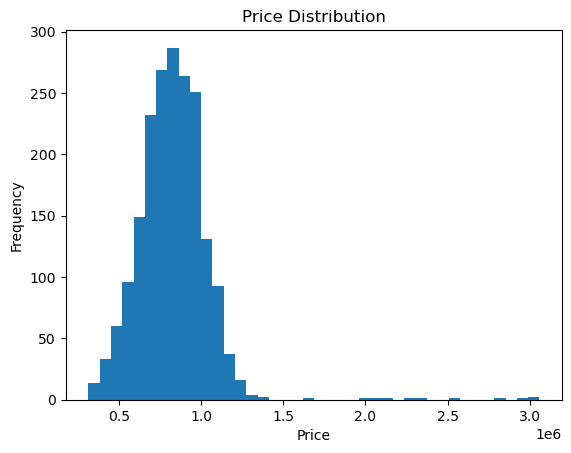

In [5]:
# 2) Visualizations
plt.figure()
df['price'].astype(float).plot(kind='hist', bins=40, title='Price Distribution')
plt.xlabel('Price'); plt.ylabel('Frequency'); plt.show()

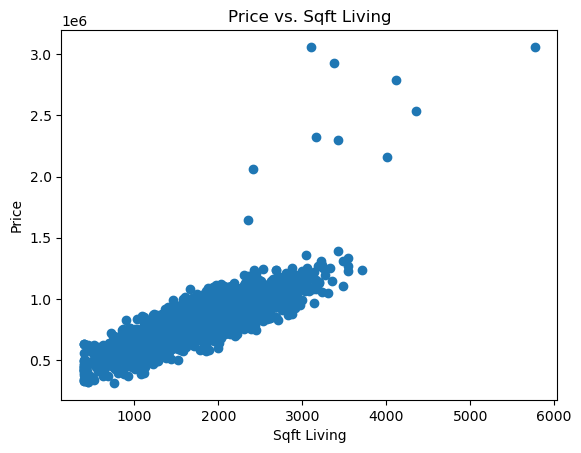

In [6]:
plt.figure()
plt.scatter(df['sqft_living'].astype(float), df['price'].astype(float))
plt.title('Price vs. Sqft Living'); plt.xlabel('Sqft Living'); plt.ylabel('Price'); plt.show()


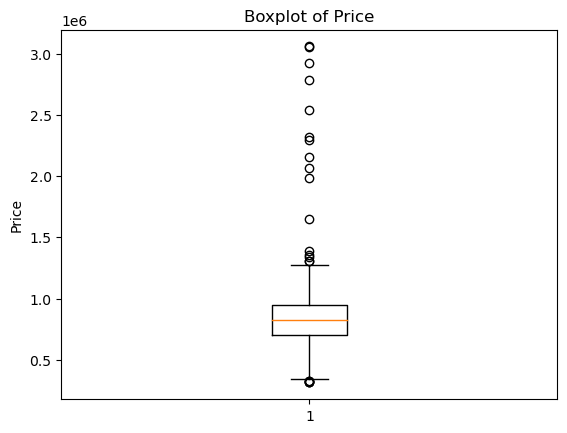

In [7]:
plt.figure()
plt.boxplot(df['price'].astype(float).dropna())
plt.title('Boxplot of Price'); plt.ylabel('Price'); plt.show()


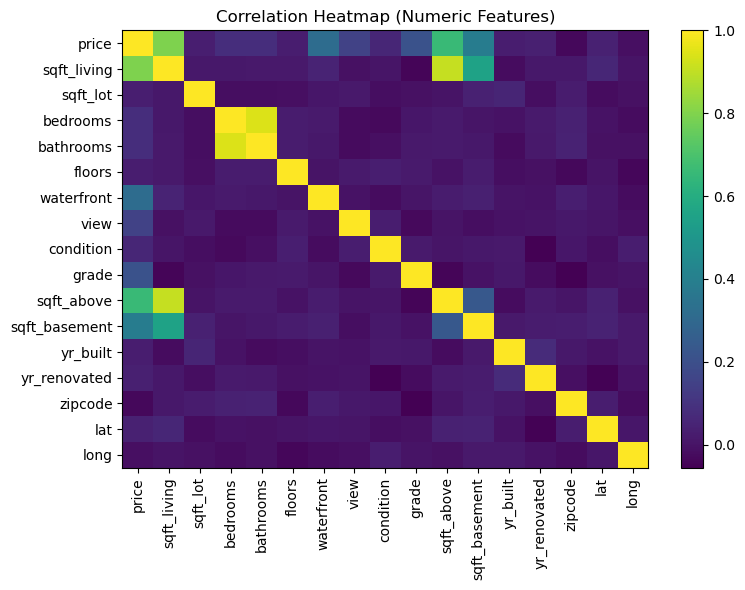

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].astype(float).corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar(); plt.title('Correlation Heatmap (Numeric Features)'); plt.tight_layout(); plt.show()


In [6]:
# 3) Outlier removal (IQR) on price and sqft_living
def iqr_filter(frame, cols, k=1.5):
    mask = np.ones(len(frame), dtype=bool)
    for c in cols:
        series = frame[c].astype(float)
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - k*iqr, q3 + k*iqr
        mask &= series.between(low, high, inclusive='both')
    return frame[mask]

df_clean = iqr_filter(df, ['price', 'sqft_living'])

In [13]:
# 4) Split 80/20
target = 'price'
X = df_clean.drop(columns=[target])
y = df_clean[target].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

print(X_train[:5])

      sqft_living  sqft_lot  bedrooms  bathrooms  floors  waterfront  view  \
1539       2710.0    3929.0       4.0        4.2     1.0         1.0   NaN   
1767       2305.0   10231.0       2.0        1.3     1.0         1.0   0.0   
506        3252.0   15609.0       3.0        2.5     2.0         1.0   3.0   
350        2021.0   11258.0       1.0        1.0     2.0         1.0   3.0   
306        1599.0   17677.0       2.0        3.0     2.0         1.0   4.0   

      condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  \
1539        1.0    7.0      1925.0          785.0    1983.0           0.0   
1767        3.0    4.0      1837.0          468.0    1965.0        2016.0   
506         5.0    5.0      2179.0            NaN    1974.0           0.0   
350         3.0    4.0      1733.0          288.0       NaN           0.0   
306         5.0   11.0      1087.0          512.0    1991.0           0.0   

      zipcode        lat        long has_garage renovated  
1539  98

In [15]:

# 5) Preprocess: impute, ordinal-encode, scale; Feature selection (SelectKBest with mutual_info_regression)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(numeric_features)
print(categorical_features)

['sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long']
['has_garage', 'renovated']


#### SimpleImputer(strategy='median') : Fills missing values in numeric columns, with median of the column
#### Pipeline for Categoricals works as:
---
df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', None],
    'shape': ['circle', 'square', None, 'circle', 'triangle']
})
print(df)
```
   color     shape
0    red    circle
1   blue    square
2  green      None
3    red    circle
4   None  triangle
```
---
### **Fit and Transform**
```python
transformed = categorical_pipeline.fit_transform(df)
```
1. **`SimpleImputer(strategy='most_frequent')`**
   * Fills missing values with the **most frequent value** in each column:
     * `color`: most frequent = `'red'` → replaces `None` in row 4
     * `shape`: most frequent = `'circle'` → replaces `None` in row 2
   ```
      color     shape
   0    red    circle
   1   blue    square
   2  green    circle
   3    red    circle
   4    red  triangle
   ```
2. **`OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)`**
   * Converts categories to integer codes:
     * `color`: {'blue': 0, 'green': 1, 'red': 2}
     * `shape`: {'circle': 0, 'square': 1, 'triangle': 2}
   ```
   [[2. 0.]
    [0. 1.]
    [1. 0.]
    [2. 0.]
    [2. 2.]]
   ```

In [18]:
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

1. ColumnTransformer allows you to apply different preprocessing pipelines to different columns of a DataFrame.
    1) 'num' → applies numeric_pipeline to numeric_features
    2) 'cat' → applies categorical_pipeline to categorical_features
    3) remainder='drop' → drops all columns not listed in numeric_features or categorical_features.

2. feature_selector = SelectKBest(mutual_info_regression, k=12)
    1) Selects the top k features that have the highest relationship with the target variable.
    2) mutual_info_regression measures dependency between each feature and the target (non-linear and non-parametric)

In [ ]:
preprocess = ColumnTransformer([('num', numeric_pipeline, numeric_features), ('cat', categorical_pipeline, categorical_features)], remainder='drop')
feature_selector = SelectKBest(mutual_info_regression, k=12)

In [20]:
# --------------------
# Preprocessing
# --------------------
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

X_train_sel = feature_selector.fit_transform(X_train_prep, y_train)
X_test_sel = feature_selector.transform(X_test_prep)

print(X_train_sel[:5])
print(X_test_sel[:5])

[[ 1.61759448 -0.96938726  1.03717709  0.0450213  -0.1963362   1.16859605
   1.74253964 -0.50841383 -0.92521193  0.33373168  1.          0.        ]
 [ 0.91555289 -0.96938726  1.03717709 -1.38791464 -1.25426428  0.98316722
   0.30698718  1.99253279 -0.39300738 -0.06387026  1.          1.        ]
 [ 2.5571168   1.03157947  1.03717709  0.76148927 -0.90162159  1.70381111
  -0.13681137 -0.50841383  0.67498909 -0.93974351  1.          0.        ]
 [ 0.42325706  1.03157947  1.03717709  0.76148927 -1.25426428  0.76402404
  -0.50815301 -0.50841383  0.26501734 -0.5693655   1.          0.        ]
 [-0.30825295  1.03157947  1.03717709  1.47795724  1.21423457 -0.59719219
   0.50624367 -0.50841383 -1.96780605  0.07397985  0.          0.        ]]
[[ 0.04710144  1.03157947  1.03717709  0.0450213  -0.1963362  -0.02404851
   0.20283038 -0.50841383 -1.91776684  0.0486601   0.          0.        ]
 [-0.15744401 -0.96938726 -0.9641555  -0.67144667  0.15630649  0.36366633
  -0.13681137 -0.50841383 -0.96

In [15]:
# --------------------
# Linear Regression
# --------------------
lr = LinearRegression()
lr.fit(X_train_sel, y_train)
y_pred_lr = lr.predict(X_test_sel)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("MAE ",mae_lr)
print("MSE ",mse_lr)
print("RMSE ",rmse_lr)


MAE  33764.77293367926
MSE  1885114518.6609032
RMSE  43417.90550753114


In [16]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_sel, y_train)
y_pred_dt = dt.predict(X_test_sel)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("MAE ",mae_dt)
print("MSE ",mse_dt)
print("RMSE ",rmse_dt)

MAE  63624.678706199455
MSE  6312188910.418885
RMSE  79449.28514731197


In [17]:
# --------------------
# Random Forest
# --------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sel, y_train)
y_pred_rf = rf.predict(X_test_sel)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("MAE ",mae_rf)
print("MSE ",mse_rf)
print("RMSE ",rmse_rf)

MAE  42918.355086657706
MSE  3022526007.046144
RMSE  54977.50455455526


In [18]:
# --------------------
# KNN
# --------------------
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_sel, y_train)
y_pred_knn = knn.predict(X_test_sel)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)

print("MAE ",mae_knn)
print("MSE ",mse_knn)
print("RMSE ",rmse_knn)


MAE  56178.61492876397
MSE  5167396207.702412
RMSE  71884.60341201314


In [19]:
# --------------------
# SVM
# --------------------
svm = SVR(kernel='rbf', C=10.0, epsilon=0.2)
svm.fit(X_train_sel, y_train)
y_pred_svm = svm.predict(X_test_sel)

mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)

print("MAE ",mae_svm)
print("MSE ",mse_svm)
print("RMSE ",rmse_svm)


MAE  138354.18499914018
MSE  28525101271.310436
RMSE  168893.75734854868


In [20]:
# --------------------
# Naive Bayes (via binning)
# --------------------
nb_bins = 5
y_train_bins, bin_edges = pd.qcut(y_train, q=nb_bins, retbins=True, labels=False, duplicates='drop')
y_train_bins = y_train_bins.astype(int)
midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2.0

nb = GaussianNB()
nb.fit(X_train_sel, y_train_bins)

nb_pred_bins = nb.predict(X_test_sel).astype(int)
nb_pred_bins = np.clip(nb_pred_bins, 0, len(midpoints)-1)
y_pred_nb = pd.Series(nb_pred_bins).map(dict(enumerate(midpoints))).values

mae_nb = mean_absolute_error(y_test, y_pred_nb)
mse_nb = mean_squared_error(y_test, y_pred_nb)
rmse_nb = np.sqrt(mse_nb)


print("MAE ",mae_nb)
print("MSE ",mse_nb)
print("RMSE ",rmse_nb)

MAE  89879.02351482483
MSE  12149958018.31737
RMSE  110226.8479922989


In [21]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "KNN", "SVM", "Naive Bayes (binned)"],
    "MAE": [mae_lr, mae_dt, mae_rf, mae_knn, mae_svm, mae_nb],
    "MSE": [mse_lr, mse_dt, mse_rf, mse_knn, mse_svm, mse_nb],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_knn, rmse_svm, rmse_nb]
})
print(results_df.round(2))

                  Model        MAE           MSE       RMSE
0     Linear Regression   33764.77  1.885115e+09   43417.91
1         Decision Tree   63624.68  6.312189e+09   79449.29
2         Random Forest   42918.36  3.022526e+09   54977.50
3                   KNN   56178.61  5.167396e+09   71884.60
4                   SVM  138354.18  2.852510e+10  168893.76
5  Naive Bayes (binned)   89879.02  1.214996e+10  110226.85


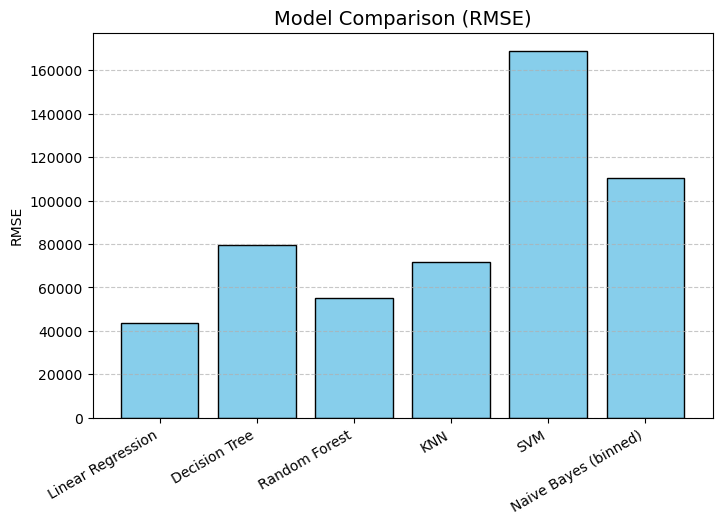

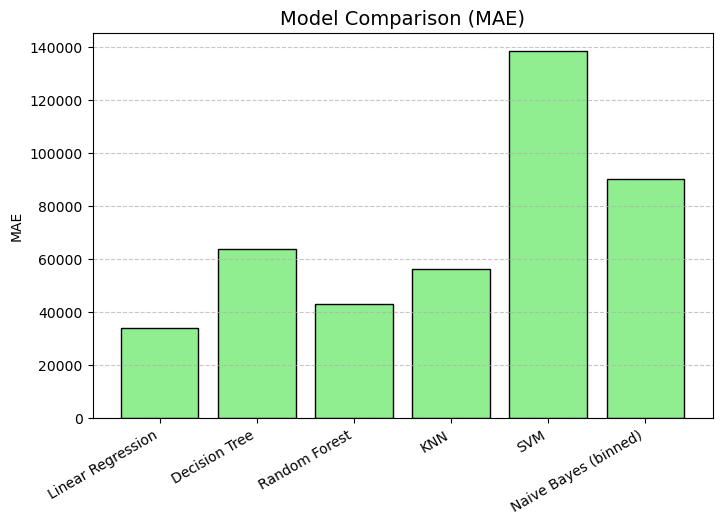

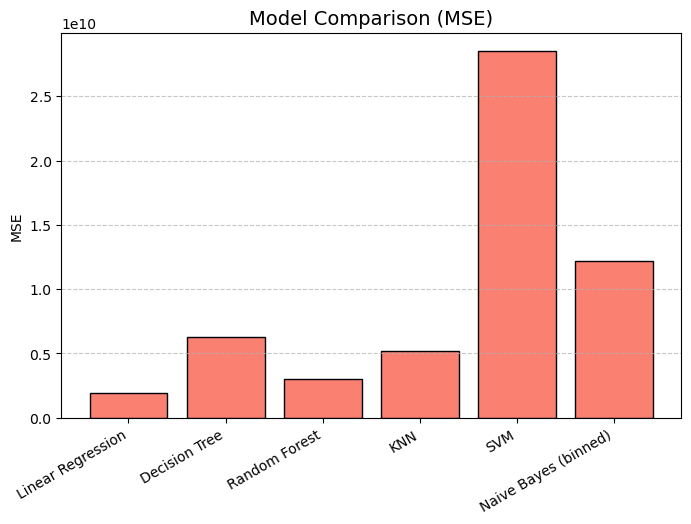

In [22]:
import matplotlib.pyplot as plt

# --- Plot RMSE Comparison ---
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"], color="skyblue", edgecolor="black")
plt.title("Model Comparison (RMSE)", fontsize=14)
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# --- Plot MAE Comparison ---
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"], color="lightgreen", edgecolor="black")
plt.title("Model Comparison (MAE)", fontsize=14)
plt.ylabel("MAE")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# --- Plot MSE Comparison ---
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MSE"], color="salmon", edgecolor="black")
plt.title("Model Comparison (MSE)", fontsize=14)
plt.ylabel("MSE")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
